| ![CC License](https://i.creativecommons.org/l/by/4.0/88x31.png) | Teks disediakan di bawah lisensi Creative Commons Attribution (CC-BY). Semua kode tersedia di bawah lisensi MIT yang disetujui oleh FSF. © Kyle T. Mandli |
|---|---|

In [1]:
from __future__ import print_function
%matplotlib inline
import numpy
import matplotlib.pyplot as plt

# Metode Numerik untuk Masalah Nilai Awal

Sekarang kita beralih ke PDE yang bergantung terhadap waktu. Sebelum masuk ke PDE secara penuh, kita akan mengeksplorasi metode numerik untuk sistem ODE yang merupakan masalah nilai awal dalam bentuk umum:

$$
\frac{\text{d} \vec{u}}{\text{d}t} = \vec{f}(t, \vec{u}) \quad \vec{u}(0) = \vec{u}_0
$$

di mana:
- $\vec{u}(t)$ adalah vektor keadaan (state vector)
- $\vec{f}(t, \vec{u})$ adalah fungsi bernilai vektor yang mengontrol pertumbuhan $\vec{u}$ terhadap waktu
- $\vec{u}(0)$ adalah kondisi awal pada waktu $t = 0$

Perlu dicatat bahwa fungsi di ruas kanan, $\vec{f}$, sebenarnya bisa merupakan hasil diskretisasi ruang dari suatu PDE, yaitu sebuah sistem persamaan.

#### Contoh: Peluruhan Radioaktif Sederhana  
$\vec{u} = [c]$

$$
\frac{\text{d} c}{\text{d}t} = -\lambda c \quad c(0) = c_0
$$

yang memiliki solusi dalam bentuk $c(t) = c_0 e^{-\lambda t}$

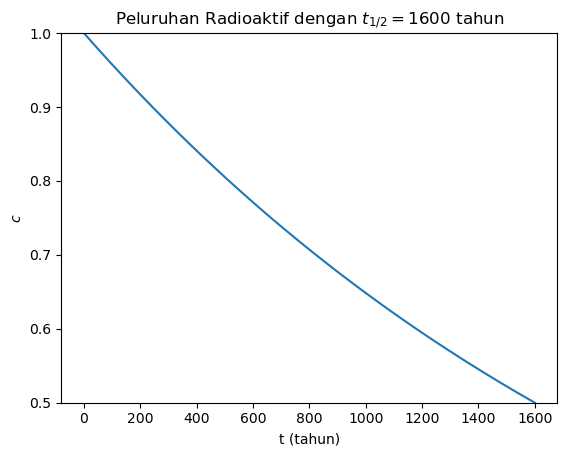

In [2]:
t = numpy.linspace(0.0, 1.6e3, 100)
c_0 = 1.0
konstanta_peluruhan = numpy.log(2.0) / 1600.0

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, c_0 * numpy.exp(-konstanta_peluruhan * t))

axes.set_title("Peluruhan Radioaktif dengan $t_{1/2} = 1600$ tahun")
axes.set_xlabel('t (tahun)')
axes.set_ylabel('$c$')
axes.set_ylim((0.5, 1.0))
plt.show()

#### Contoh: Peluruhan Radioaktif Kompleks (atau Sistem Kimia)

Rantai peluruhan dari satu spesies ke spesies lainnya.

$$
\begin{aligned}
\frac{\text{d} c_1}{\text{d}t} &= -\lambda_1 c_1 \\
\frac{\text{d} c_2}{\text{d}t} &= \lambda_1 c_1 - \lambda_2 c_2 \\
\frac{\text{d} c_3}{\text{d}t} &= \lambda_2 c_2 - \lambda_3 c_3 
\end{aligned}
$$

$$
\frac{\text{d} \vec{u}}{\text{d}t} = \frac{\text{d}}{\text{d}t}
\begin{bmatrix} c_1 \\ c_2 \\ c_3 \end{bmatrix} = 
\begin{bmatrix} 
-\lambda_1 & 0 & 0 \\
\lambda_1 & -\lambda_2 & 0 \\
0 & \lambda_2 & -\lambda_3
\end{bmatrix}
\begin{bmatrix} c_1 \\ c_2 \\ c_3 \end{bmatrix}
$$

$$
\frac{\text{d} \vec{u}}{\text{d}t} = A \vec{u}
$$

Untuk sistem persamaan seperti ini, solusi umum dari ODE adalah eksponensial matriks:

$$
\vec{u}(t) = \vec{u}_0 e^{A t}
$$

#### Contoh: Osilator Van der Pol

$$
y'' - \mu (1 - y^2) y' + y = 0 
~~~~~\text{dengan}~~~~ 
y(0) = y_0, ~~~y'(0) = v_0
$$
 
$$
\vec{u} = 
\begin{bmatrix} y \\ y' \end{bmatrix} = 
\begin{bmatrix} u_1 \\ u_2 \end{bmatrix}
$$
   
$$
\frac{\text{d}}{\text{d}t} 
\begin{bmatrix} u_1 \\ u_2 \end{bmatrix} = 
\begin{bmatrix} 
u_2 \\ 
\mu (1 - u_1^2) u_2 - u_1 
\end{bmatrix} 
= \vec{f}(t, \vec{u})
$$

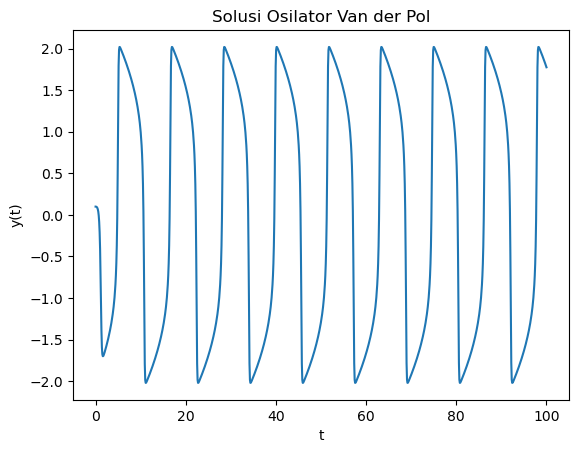

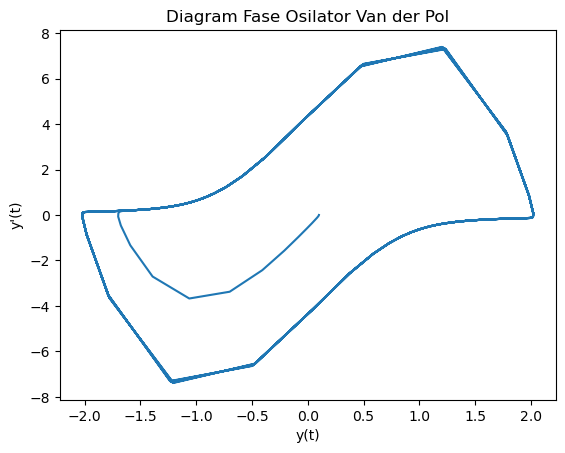

In [3]:
import scipy.integrate as integrate

def f(t, u, mu=5):
    return numpy.array([u[1], mu * (1.0 - u[0]**2) * u[1] - u[0]])

t = numpy.linspace(0.0, 100, 1000)
u = numpy.empty((2, t.shape[0]))
u[:, 0] = [0.1, 0.0]

integrator = integrate.ode(f)
integrator.set_integrator("dopri5")
integrator.set_initial_value(u[:, 0])

for (n, t_n) in enumerate(t[1:]):
    integrator.integrate(t_n)
    if not integrator.successful():
        break
    u[:, n + 1] = integrator.y
    
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.plot(t, u[0, :])
axes.set_title("Solusi Osilator Van der Pol")
axes.set_xlabel("t")
axes.set_ylabel("y(t)")

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.plot(u[0, :], u[1, :])
axes.set_title("Diagram Fase Osilator Van der Pol")
axes.set_xlabel("y(t)")
axes.set_ylabel("y'(t)")

plt.show()

#### Contoh: Persamaan Panas (Heat Equation)

Mari kita coba membangun sistem ODE yang merepresentasikan persamaan panas:
$$
u_t = u_{xx}.
$$

Jika kita mendiskretisasi ruas kanan dengan beda hingga orde dua (second order), menggunakan skema beda terpusat (centered differences) dengan $m$ titik, maka diperoleh:
$$
\frac{\text{d}}{\text{d} t} U_i(t) = \frac{U_{i+1}(t) - 2 U_i(t) + U_{i-1}(t)}{\Delta x^2}
$$

di mana sekarang terdapat $m$ fungsi tak diketahui yang bergantung pada waktu dan harus diselesaikan. Pendekatan untuk mendiskretisasi PDE seperti ini kadang disebut sebagai *method of lines*.

## Eksistensi dan Keunikan Solusi

Salah satu langkah penting sebelum mempelajari metode numerik untuk masalah ODE nilai awal (IVP) adalah memahami bagaimana perilaku solusi, apakah solusi tersebut ada (eksis), dan apakah solusi tersebut bersifat unik.

### Sistem Linear

Untuk ODE linear, kita memiliki sistem umum:
$$
u'(t) = A(t) u + g(t)
$$

di mana $A$ adalah matriks yang bergantung pada waktu dan $g$ adalah sebuah vektor. Perlu dicatat bahwa sistem linear selalu memiliki solusi yang unik.

Jika $g(t) = 0$ untuk semua $t$, maka ODE tersebut disebut *homogen*. Jika matriks $A$ tidak bergantung pada waktu (time independent), maka sistem tersebut juga disebut *otonom* (*autonomous*). Dalam kondisi ini, solusi dari ODE adalah:

$$
u(t) = u(t_0) e^{A(t - t_0)}.
$$

Jika $g(t) \neq 0$ untuk semua $t$, maka ODE tersebut disebut *tak homogen* (*inhomogeneous*). Untuk kasus ini, kita dapat menggunakan prinsip Duhamel yang menyatakan bahwa:

$$
u(t) = u(t_0) e^{A(t-t_0)} + \int^t_{t_0} e^{A(t - \tau)} g(\tau) \, d\tau.
$$

Operator $e^{A(t-\tau)}$ dapat dipandang sebagai operator solusi untuk ODE homogen, yang memetakan solusi pada waktu $\tau$ ke solusi pada waktu $t$. Hal ini membuat bentuk solusi ini memiliki sifat seperti fungsi Green (*Green's function*).


### Eksistensi dan Keunikan Nonlinear

#### Kontinuitas Lipschitz

Untuk menggeneralisasi keunikan pada ODE non-linear, diperlukan jenis kontinuitas khusus yang disebut *kontinuitas Lipschitz*. Misalkan ODE berikut:
$$
u'(t) = f(u,t), \quad \quad \quad u(t_0) = u_0,
$$

kita memerlukan tingkat kehalusan (smoothness) tertentu pada fungsi ruas kanan $f(u,t)$.

Kita mengatakan bahwa $f$ bersifat *kontinu Lipschitz* terhadap $u$ pada suatu domain

$$
\Omega = \{(u,t) : |u - u_0| \leq a, \; t_0 \leq t \leq t_1 \}
$$

jika terdapat suatu konstanta $L > 0$ sehingga

$$
|f(u,t) - f(u^\ast, t)| \leq L |u - u^\ast| 
\quad \quad \forall (u,t) ~\text{dan}~ (u^\ast,t) \in \Omega.
$$

Jika $f(u,t)$ terdiferensialkan terhadap $u$ di $\Omega$, yaitu Jacobian $f_u = \partial f / \partial u$ ada dan terbatas (bounded), maka kita dapat menyatakan bahwa

$$
L = \max_{(u,t) \in \Omega} |f_u(u,t)|.
$$

Kita dapat menggunakan batas ini karena

$$
f(u,t) = f(u^\ast, t) + f_u(v,t)(u-u^\ast)
$$

untuk suatu $v$ yang berada di antara $u$ dan $u^\ast$. Hal ini pada dasarnya merupakan batas galat dari deret Taylor dan menunjukkan bahwa fungsi $f$ bersifat halus (*smooth*).

Dengan adanya kontinuitas Lipschitz pada $f$, kita dapat menjamin bahwa solusi IVP adalah unik, setidaknya hingga waktu

$$
T = \min(t_1, t_0 + a/S)
$$

dengan

$$
S = \max_{(u,t)\in\Omega} |f(u,t)|.
$$

Nilai $S$ ini merupakan nilai maksimum dari kemiringan (slope) yang dapat dicapai oleh solusi $u(t)$ di dalam $\Omega$, sehingga menjamin bahwa solusi tetap berada di dalam domain $\Omega$.

#### Contoh

Pertimbangkan $u'(t) = (u(t))^2, \; u(0) = u_0 > 0$. Jika kita mendefinisikan domain yang kita tinjau seperti sebelumnya, maka konstanta Lipschitz dapat dihitung sebagai

$$
L = \max_{(u,t) \in \Omega} | 2 u | = 2 (u_0 + a)
$$

di mana kita menggunakan batasan dari $\Omega$ yaitu $|u - u_0| \leq a$.

Dengan cara yang sama, kita dapat menghitung $S$ sehingga diperoleh

$$
S = \max_{(u,t)\in\Omega} |f(u,t)| = (u_0 + a)^2
$$

sehingga kita dapat menjamin solusi unik hingga waktu

$$
T = \frac{a}{(u_0 + a)^2}.
$$

Karena kita dapat memilih nilai $a$, kita dapat memilih nilai yang memaksimalkan $T$. Dalam kasus ini, $a = u_0$ memberikan nilai maksimum tersebut, sehingga diperoleh bahwa solusi unik berlaku hingga

$$
T = \frac{1}{4u_0}.
$$

Karena kita juga mengetahui solusi eksak dari ODE di atas,

$$
u(t) = \frac{1}{1/u_0 - t},
$$

kita dapat melihat bahwa $|u(t)| < \infty$ selama $t \neq 1/u_0$. Perhatikan bahwa ketika kita mencapai titik singularitas (pole) pada penyebut, maka tidak ada lagi solusi yang mungkin untuk IVP setelah titik tersebut.

#### Contoh

Pertimbangkan IVP berikut:
$$
u' = \sqrt{u} \quad \quad u(0) = 0.
$$

Di mana fungsi $f$ ini bersifat kontinu Lipschitz?

Fungsi $f(u) = \sqrt{u}$ **tidak Lipschitz kontinu di sekitar $u = 0$**. Hal ini karena turunan terhadap $u$ adalah

$$
f_u = \frac{1}{2\sqrt{u}},
$$

yang **tidak terbatas (tak hingga)** saat $u \to 0$.  

Namun, $f(u)$ **Lipschitz kontinu pada domain yang tidak mencakup nol**, misalnya untuk $u \geq \delta > 0$, karena pada domain tersebut turunan $f_u$ terbatas.

Jadi, kesimpulannya:
- Tidak Lipschitz di sekitar $u = 0$
- Lipschitz pada interval $u > 0$ yang menjauh dari nol

Dengan menghitung turunannya, diperoleh

$$
f_u = \frac{1}{2\sqrt{u}}
$$

yang menuju tak hingga saat $u \rightarrow 0$. Oleh karena itu, kita tidak dapat menjamin keunikan solusi di sekitar kondisi awal yang diberikan.  

Faktanya, kita mengetahui bahwa ODE ini memiliki dua solusi, yaitu

$$
u(t) = 0 \quad \text{dan} \quad u(t) = \frac{1}{4} t^2.
$$

### Sistem Persamaan

Konsep yang serupa untuk kontinuitas Lipschitz juga berlaku pada suatu norma tertentu $||\cdot||$, yaitu jika terdapat konstanta $L$ sehingga

$$
||f(u,t) - f(u^\ast,t)|| \leq L ||u - u^\ast||
$$

untuk semua $(u,t)$ dan $(u^\ast,t)$ dalam domain

$$
\Omega = \{(u,t) : ||u-u_0|| \leq a, \; t_0 \leq t \leq t_1 \}.
$$

Perlu dicatat bahwa jika fungsi $f$ bersifat Lipschitz kontinu dalam satu norma, maka ia juga kontinu dalam norma lainnya.

## Skema Langkah Dasar

Jika kita melihat kembali pada pembahasan tentang diferensiasi numerik, mengapa tidak mendekati turunan dengan beda hingga:

$$
\frac{u(t + \Delta t) - u(t)}{\Delta t} = f(t, u)
$$

Namun, kita masih perlu menentukan bagaimana cara mengevaluasi suku $f(t, u)$ tersebut.

Mari kita lihat ini dari sudut pandang kuadratur (integrasi numerik), dengan mengambil integral pada kedua sisi:

$$
\begin{aligned}
\int^{t + \Delta t}_t \frac{\text{d} u}{\text{d}\tilde{t}} \, d\tilde{t} &= \int^{t + \Delta t}_t f(t, u) \, d\tilde{t} \\ ~ \\
u(t + \Delta t) - u(t) &= \Delta t ~f(t, u(t)) \\ ~ \\
\frac{u(t + \Delta t) - u(t)}{\Delta t} &= f(t, u(t))
\end{aligned}
$$

di mana kita menggunakan aturan kuadratur sisi kiri (*left-sided quadrature rule*) untuk integral di ruas kanan.

Untuk menyederhanakan, kita perkenalkan beberapa notasi:

$$
t_0 = 0 \quad \quad t_1 = t_0 + \Delta t \quad \quad t_n = t_{n-1} + \Delta t = n \Delta t + t_0
$$

$$
U^0 = u(t_0) \quad \quad U^1 = u(t_1) \quad \quad U^n = u(t_n)
$$

Sehingga skema yang diperoleh dapat dituliskan kembali sebagai:

$$
\frac{U^{n+1} - U^n}{\Delta t} = f(t_n, U^n)
$$

atau

$$
U^{n+1} = U^n + \Delta t \, f(t_n, U^n)
$$

yang dikenal sebagai *metode Euler maju* (*forward Euler method*). Pada dasarnya, kita mendekati turunan menggunakan nilai fungsi pada titik saat ini, yaitu $t_n$.

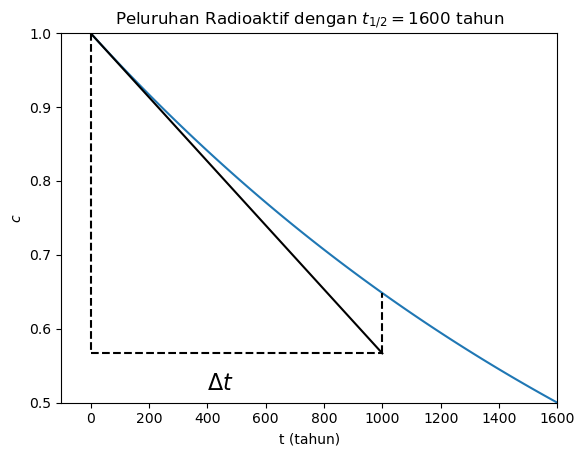

In [4]:
t = numpy.linspace(0.0, 1.6e3, 100)
c_0 = 1.0
konstanta_peluruhan = numpy.log(2.0) / 1600.0

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, c_0 * numpy.exp(-konstanta_peluruhan * t), label="Solusi Sebenarnya")

# Plot langkah Euler
dt = 1e3
u_np = c_0 + dt * (-konstanta_peluruhan * c_0)
axes.plot((0.0, dt), (c_0, u_np), 'k')
axes.plot((dt, dt), (u_np, c_0 * numpy.exp(-konstanta_peluruhan * dt)), 'k--')
axes.plot((0.0, 0.0), (c_0, u_np), 'k--')
axes.plot((0.0, dt), (u_np, u_np), 'k--')
axes.text(400, u_np - 0.05, '$\\Delta t$', fontsize=16)

axes.set_title("Peluruhan Radioaktif dengan $t_{1/2} = 1600$ tahun")
axes.set_xlabel('t (tahun)')
axes.set_ylabel('$c$')
axes.set_xlim(-1e2, 1.6e3)
axes.set_ylim((0.5, 1.0))
plt.show()

Perhatikan di mana kita mengharapkan adanya kesalahan (error) akibat pendekatan ini dan bagaimana kesalahan tersebut muncul pada contoh di bawah.

Kesalahan terjadi karena metode Euler maju menggunakan kemiringan (slope) di titik awal $t_n$ untuk memperkirakan nilai pada $t_{n+1}$. Padahal, solusi sebenarnya tidak linear (melengkung), sehingga:

- Garis lurus hasil pendekatan Euler akan **menyimpang dari kurva eksak**.
- Semakin besar $\Delta t$, maka **error akan semakin besar**.
- Error ini muncul sebagai **selisih vertikal antara solusi numerik dan solusi eksak** pada waktu $t_{n+1}$.
- Secara visual, terlihat bahwa hasil Euler “melewati” atau “tidak mengikuti” kurva eksponensial dengan tepat.

Dengan kata lain, error berasal dari asumsi bahwa fungsi berubah secara linear dalam interval $\Delta t$, padahal sebenarnya tidak.

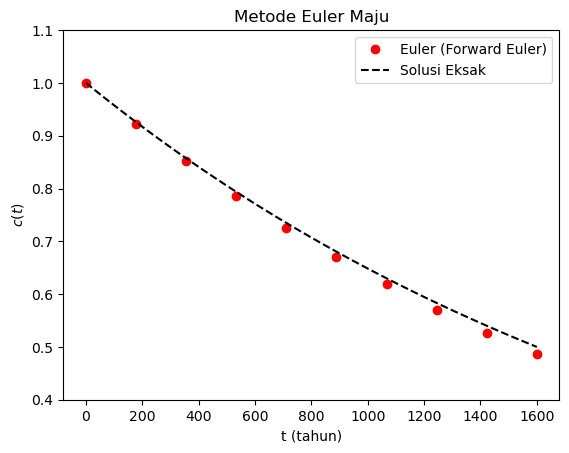

In [5]:
c_0 = 1.0
konstanta_peluruhan = numpy.log(2.0) / 1600.0
f = lambda t, u: -konstanta_peluruhan * u

t_exact = numpy.linspace(0.0, 1.6e3, 100)
u_exact = c_0 * numpy.exp(-konstanta_peluruhan * t_exact)

# Implementasi Euler
t = numpy.linspace(0.0, 1.6e3, 10)
delta_t = t[1] - t[0]
U = numpy.empty(t.shape)
U[0] = c_0

for (n, t_n) in enumerate(t[:-1]):
    U[n + 1] = U[n] + delta_t * f(t_n, U[n])

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, U, 'or', label="Euler (Forward Euler)")
axes.plot(t_exact, u_exact, 'k--', label="Solusi Eksak")

axes.set_title("Metode Euler Maju")
axes.set_xlabel("t (tahun)")
axes.set_ylabel("$c(t)$")
axes.set_ylim((0.4, 1.1))
axes.legend()

plt.show()

Metode serupa dapat diturunkan jika kita menggunakan beda hingga pusat (*central difference*) dengan akurasi orde dua:

$$
\frac{U^{n+1} - U^{n-1}}{2\Delta t} = f(t_{n}, U^{n})
$$

Metode ini dikenal sebagai *leap-frog method*. Perlu dicatat bahwa bentuk metode ini membutuhkan evaluasi pada langkah sebelumnya, sehingga secara teknis merupakan metode *multi-step*, meskipun tidak menggunakan evaluasi pada titik waktu saat ini secara langsung.

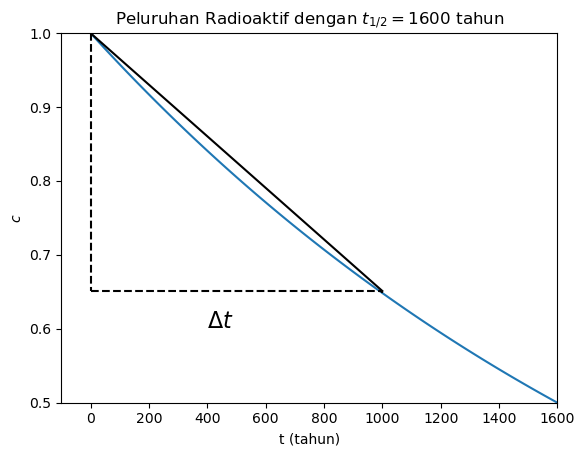

In [6]:
t = numpy.linspace(0.0, 1.6e3, 100)
c_0 = 1.0
konstanta_peluruhan = numpy.log(2.0) / 1600.0

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, c_0 * numpy.exp(-konstanta_peluruhan * t), label="Solusi Eksak")

# Plot langkah Leap-Frog
dt = 1e3
u_np = c_0 + dt * (-konstanta_peluruhan * c_0 * numpy.exp(-konstanta_peluruhan * dt / 2.0))

axes.plot((0.0, dt), (c_0, u_np), 'k')
axes.plot((dt, dt), (u_np, c_0 * numpy.exp(-konstanta_peluruhan * dt)), 'k--')
axes.plot((0.0, 0.0), (c_0, u_np), 'k--')
axes.plot((0.0, dt), (u_np, u_np), 'k--')
axes.text(400, u_np - 0.05, '$\\Delta t$', fontsize=16)

axes.set_title("Peluruhan Radioaktif dengan $t_{1/2} = 1600$ tahun")
axes.set_xlabel('t (tahun)')
axes.set_ylabel('$c$')
axes.set_xlim(-1e2, 1.6e3)
axes.set_ylim((0.5, 1.0))

plt.show()

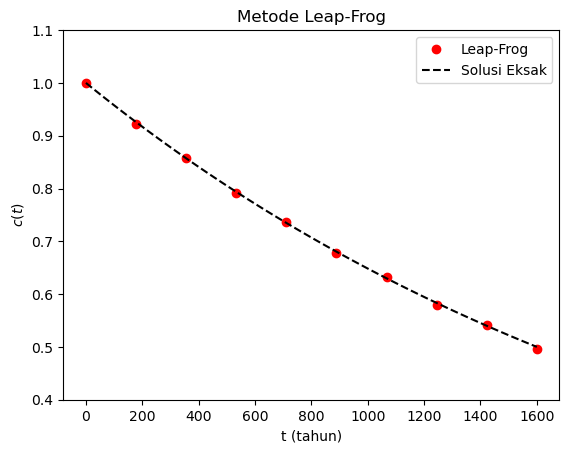

In [7]:
c_0 = 1.0
konstanta_peluruhan = numpy.log(2.0) / 1600.0
f = lambda t, u: -konstanta_peluruhan * u

t_exact = numpy.linspace(0.0, 1.6e3, 100)
u_exact = c_0 * numpy.exp(-konstanta_peluruhan * t_exact)

# Implementasi Leap-Frog
t = numpy.linspace(0.0, 1.6e3, 10)
delta_t = t[1] - t[0]
U = numpy.empty(t.shape)
U[0] = c_0

# Inisialisasi pertama menggunakan Euler
U[1] = U[0] + delta_t * f(t[0], U[0])

for n in range(1, t.shape[0] - 1):
    U[n + 1] = U[n - 1] + 2.0 * delta_t * f(t[n], U[n])

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, U, 'or', label="Leap-Frog")
axes.plot(t_exact, u_exact, 'k--', label="Solusi Eksak")

axes.set_title("Metode Leap-Frog")
axes.set_xlabel("t (tahun)")
axes.set_ylabel("$c(t)$")
axes.set_ylim((0.4, 1.1))
axes.legend()

plt.show()

Mirip dengan metode Euler maju, terdapat juga metode *Euler mundur* (*backward Euler method*) yang mengevaluasi fungsi $f$ pada waktu yang sudah diperbarui (aturan kuadratur sisi kanan / right-hand quadrature), sehingga diperoleh:

$$
U^{n+1} = U^n + \Delta t \, f(t_{n+1}, U^{n+1}).
$$

Skema di mana fungsi $f$ dievaluasi pada waktu yang belum diketahui (unknown time level) disebut sebagai *metode implisit* (*implicit methods*).

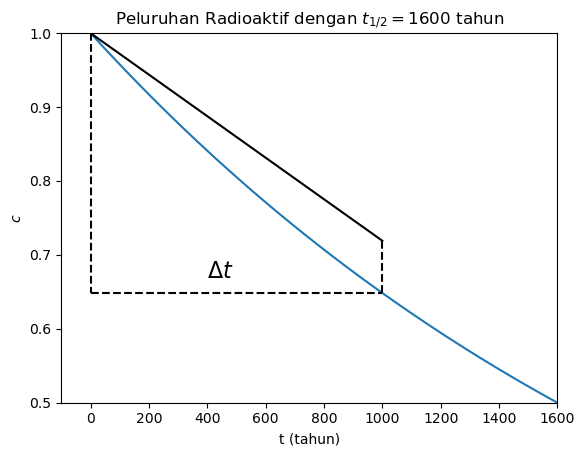

In [8]:
t = numpy.linspace(0.0, 1.6e3, 100)
c_0 = 1.0
konstanta_peluruhan = numpy.log(2.0) / 1600.0

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, c_0 * numpy.exp(-konstanta_peluruhan * t), label="Solusi Eksak")

# Plot langkah Euler
dt = 1e3
u_np = c_0 + dt * (-konstanta_peluruhan * c_0 * numpy.exp(-konstanta_peluruhan * dt))

axes.plot((0.0, dt), (c_0, u_np), 'k')
axes.plot((dt, dt), (u_np, c_0 * numpy.exp(-konstanta_peluruhan * dt)), 'k--')
axes.plot((0.0, 0.0), (c_0, c_0 * numpy.exp(-konstanta_peluruhan * dt)), 'k--')
axes.plot((0.0, dt), (c_0 * numpy.exp(-konstanta_peluruhan * dt),
                      c_0 * numpy.exp(-konstanta_peluruhan * dt)), 'k--')

axes.text(400, u_np - 0.05, '$\\Delta t$', fontsize=16)

axes.set_title("Peluruhan Radioaktif dengan $t_{1/2} = 1600$ tahun")
axes.set_xlabel('t (tahun)')
axes.set_ylabel('$c$')
axes.set_xlim(-1e2, 1.6e3)
axes.set_ylim((0.5, 1.0))

plt.show()

Tuliskan kode yang mengimplementasikan metode *backward Euler*:

$$
U^{n+1} = U^n + \Delta t \, f(t_{n+1}, U^{n+1}).
$$

Perhatikan pada implementasi berikut bagaimana bias error yang muncul, dan hubungkan kembali hal tersebut dengan pendekatan yang digunakan dalam metode ini.

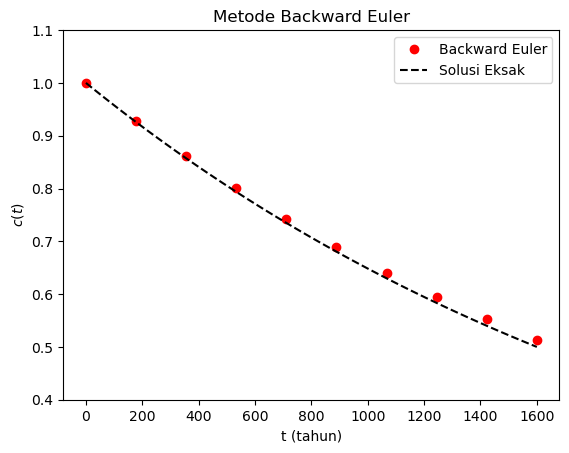

In [9]:
c_0 = 1.0
konstanta_peluruhan = numpy.log(2.0) / 1600.0
f = lambda t, u: -konstanta_peluruhan * u

t_exact = numpy.linspace(0.0, 1.6e3, 100)
u_exact = c_0 * numpy.exp(-konstanta_peluruhan * t_exact)

# Implementasi Backward Euler
t = numpy.linspace(0.0, 1.6e3, 10)
delta_t = t[1] - t[0]
U = numpy.empty(t.shape)
U[0] = c_0

for n in range(0, t.shape[0] - 1):
    U[n + 1] = U[n] / (1.0 + konstanta_peluruhan * delta_t)

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, U, 'or', label="Backward Euler")
axes.plot(t_exact, u_exact, 'k--', label="Solusi Eksak")

axes.set_title("Metode Backward Euler")
axes.set_xlabel("t (tahun)")
axes.set_ylabel("$c(t)$")
axes.set_ylim((0.4, 1.1))
axes.legend()

plt.show()

Modifikasi dari metode Euler melibatkan penggunaan titik tengah teraproksimasi untuk mengevaluasi $f(t, u)$ yang disebut *metode titik tengah* (midpoint method). Skemanya adalah

$$
\frac{U^{n+1} - U^{n}}{\Delta t} = f\left(\frac{U^n + U^{n+1}}{2} \right).
$$

Metode ini merupakan contoh paling sederhana dari *integrator simplektik* (*symplectic integrator*), yang memiliki sifat khusus ketika digunakan untuk mengintegrasikan sistem Hamiltonian.

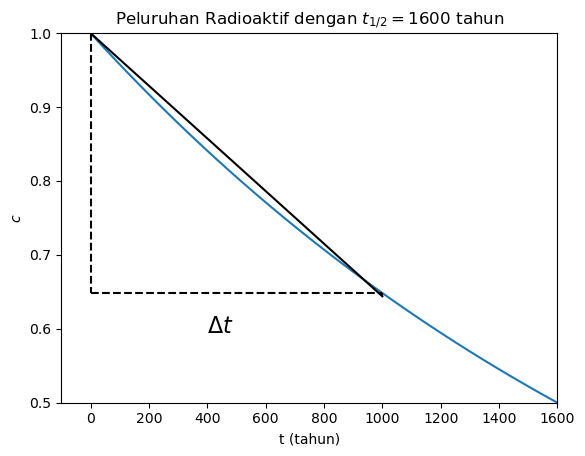

In [10]:
t = numpy.linspace(0.0, 1.6e3, 100)
c_0 = 1.0
konstanta_peluruhan = numpy.log(2.0) / 1600.0

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, c_0 * numpy.exp(-konstanta_peluruhan * t), label="Solusi Eksak")

# Plot langkah Midpoint
dt = 1e3
u_np = c_0 * (1.0 - konstanta_peluruhan * dt / 2.0) / (1.0 + konstanta_peluruhan * dt / 2.0)

axes.plot((0.0, dt), (c_0, u_np), 'k')
axes.plot((dt, dt), (u_np, c_0 * numpy.exp(-konstanta_peluruhan * dt)), 'k--')
axes.plot((0.0, 0.0), (c_0, c_0 * numpy.exp(-konstanta_peluruhan * dt)), 'k--')
axes.plot((0.0, dt),
          (c_0 * numpy.exp(-konstanta_peluruhan * dt),
           c_0 * numpy.exp(-konstanta_peluruhan * dt)),
          'k--')

axes.text(400, u_np - 0.05, '$\\Delta t$', fontsize=16)

axes.set_title("Peluruhan Radioaktif dengan $t_{1/2} = 1600$ tahun")
axes.set_xlabel('t (tahun)')
axes.set_ylabel('$c$')
axes.set_xlim(-1e2, 1.6e3)
axes.set_ylim((0.5, 1.0))

plt.show()

Implementasikan metode titik tengah (*midpoint method*) berikut:

$$
\frac{U^{n+1} - U^{n}}{\Delta t} = f\left(\frac{U^n + U^{n+1}}{2} \right).
$$

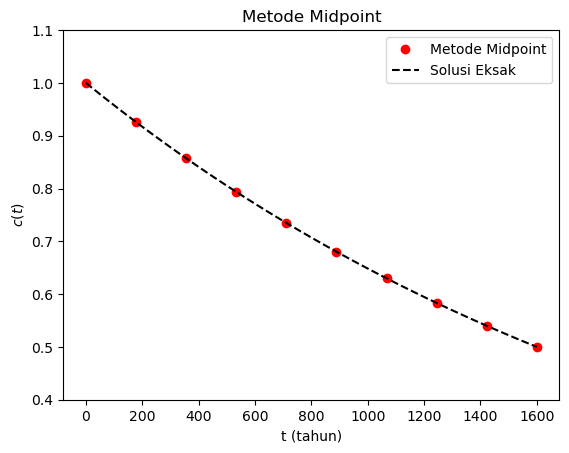

In [11]:
c_0 = 1.0
konstanta_peluruhan = numpy.log(2.0) / 1600.0
f = lambda t, u: -konstanta_peluruhan * u

t_exact = numpy.linspace(0.0, 1.6e3, 100)
u_exact = c_0 * numpy.exp(-konstanta_peluruhan * t_exact)

# Implementasi metode midpoint
t = numpy.linspace(0.0, 1.6e3, 10)
delta_t = t[1] - t[0]
U = numpy.empty(t.shape)
U[0] = c_0

faktor_integrasi = (1.0 - konstanta_peluruhan * delta_t / 2.0) / (1.0 + konstanta_peluruhan * delta_t / 2.0)

for n in range(0, t.shape[0] - 1):
    U[n + 1] = U[n] * faktor_integrasi

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, U, 'or', label="Metode Midpoint")
axes.plot(t_exact, u_exact, 'k--', label="Solusi Eksak")

axes.set_title("Metode Midpoint")
axes.set_xlabel("t (tahun)")
axes.set_ylabel("$c(t)$")
axes.set_ylim((0.4, 1.1))
axes.legend()

plt.show()

Metode implisit sederhana lainnya didasarkan pada integrasi menggunakan metode trapesium (*trapezoidal method*). Skemanya adalah:

$$
\frac{U^{n+1} - U^{n}}{\Delta t} = \frac{1}{2} \left(f(U^n) + f(U^{n+1})\right)
$$

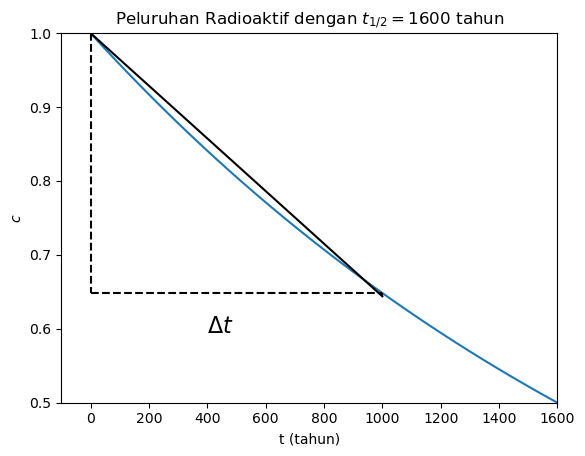

In [12]:
t = numpy.linspace(0.0, 1.6e3, 100)
c_0 = 1.0
konstanta_peluruhan = numpy.log(2.0) / 1600.0

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, c_0 * numpy.exp(-konstanta_peluruhan * t), label="Solusi Eksak")

# Plot langkah Trapesium
dt = 1e3
u_np = c_0 * (1.0 - konstanta_peluruhan * dt / 2.0) / (1.0 + konstanta_peluruhan * dt / 2.0)

axes.plot((0.0, dt), (c_0, u_np), 'k')
axes.plot((dt, dt), (u_np, c_0 * numpy.exp(-konstanta_peluruhan * dt)), 'k--')
axes.plot((0.0, 0.0), (c_0, c_0 * numpy.exp(-konstanta_peluruhan * dt)), 'k--')
axes.plot((0.0, dt),
          (c_0 * numpy.exp(-konstanta_peluruhan * dt),
           c_0 * numpy.exp(-konstanta_peluruhan * dt)),
          'k--')

axes.text(400, u_np - 0.05, '$\\Delta t$', fontsize=16)

axes.set_title("Peluruhan Radioaktif dengan $t_{1/2} = 1600$ tahun")
axes.set_xlabel('t (tahun)')
axes.set_ylabel('$c$')
axes.set_xlim(-1e2, 1.6e3)
axes.set_ylim((0.5, 1.0))

plt.show()

Implementasikan metode trapesium (*trapezoidal method*):

$$
\frac{U^{n+1} - U^{n}}{\Delta t} = \frac{1}{2} \left(f(U^n) + f(U^{n+1})\right).
$$

Apa metode ini ekuivalen dengan apa, dan mengapa demikian? Apakah hal ini selalu benar secara umum?


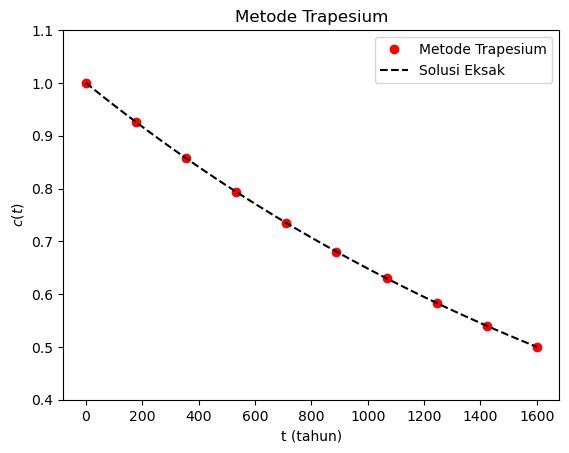

In [13]:
c_0 = 1.0
konstanta_peluruhan = numpy.log(2.0) / 1600.0

t_exact = numpy.linspace(0.0, 1.6e3, 100)
u_exact = c_0 * numpy.exp(-konstanta_peluruhan * t_exact)

# Implementasi metode trapesium
t = numpy.linspace(0.0, 1.6e3, 10)
delta_t = t[1] - t[0]

U = numpy.empty(t.shape)
U[0] = c_0

faktor_integrasi = (1.0 - konstanta_peluruhan * delta_t / 2.0) / (1.0 + konstanta_peluruhan * delta_t / 2.0)

for n in range(t.shape[0] - 1):
    U[n + 1] = U[n] * faktor_integrasi

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, U, 'or', label="Metode Trapesium")
axes.plot(t_exact, u_exact, 'k--', label="Solusi Eksak")

axes.set_title("Metode Trapesium")
axes.set_xlabel("t (tahun)")
axes.set_ylabel("$c(t)$")
axes.set_ylim((0.4, 1.1))
axes.legend()

plt.show()

## Analisis Galat

### Galat Truncation (Truncation Error)

Kita dapat mendefinisikan galat truncation seperti sebelumnya dengan cara mensubstitusikan solusi eksak ODE ke dalam persamaan beda, kemudian menggunakan ekspansi deret Taylor. Penting untuk diperhatikan bahwa pada tahap ini kita harus menggunakan bentuk beda yang secara langsung memodelkan turunan, karena jika tidak, hasilnya akan berbeda.

Definisikan pendekatan beda hingga untuk turunan sebagai $D(U^{n+1}, U^n, U^{n-1}, \ldots)$ dan tuliskan skema sebagai

$$
D(U^{n+1}, U^n, U^{n-1}, \ldots) = F(t^{n+1}, t^n, t^{n-1}, \ldots, U^{n+1}, U^n, U^{n-1}, \ldots)
$$

di mana $F(\cdot)$ berkaitan dengan evaluasi fungsi $f(t,u)$. Maka galat truncation lokal didefinisikan sebagai

$$
\tau^n = D(u(t^{n+1}), u(t^n), u(t^{n-1}), \ldots) - F(t^{n+1}, t^n, t^{n-1}, \ldots, u(t^{n+1}), u(t^n), u(t^{n-1}), \ldots)
$$

Selanjutnya, jika

$$
\lim_{\Delta t \rightarrow 0} \tau^n = 0
$$

maka skema diskret tersebut disebut **konsisten**.

Orde akurasi juga didefinisikan dengan cara yang sama seperti sebelumnya. Jika

$$
|| \tau || \leq C \Delta t^p
$$

secara seragam untuk $t \in [0, T]$, maka skema tersebut memiliki orde akurasi $p$. Perhatikan bahwa metode disebut konsisten jika $p > 0$.

---

## Analisis Galat Metode Euler Maju

Kita dapat menganalisis galat dan orde konvergensi Euler maju dengan menggunakan deret Taylor yang dikembangkan di sekitar $t_n$:

$$
u(t) = u(t_n) + (t - t_n) u'(t_n) + \frac{u''(t_n)}{2} (t - t_n)^2 + \mathcal{O}((t-t_n)^3)
$$

Evaluasi di $t_{n+1}$ memberikan:

$$
\begin{aligned}
u(t_{n+1}) &= u(t_n) + (t_{n+1} - t_n) u'(t_n) + \frac{u''(t_n)}{2} (t_{n+1} - t_n)^2 + \mathcal{O}((t_{n+1}-t_n)^3) \\
&= u(t_n) + \Delta t\, f(t_n, u(t_n)) + \frac{u''(t_n)}{2} \Delta t^2 + \mathcal{O}(\Delta t^3)
\end{aligned}
$$

Dari definisi galat truncation:

$$
\begin{aligned}
\tau^n &= \frac{u(t_{n+1}) - u(t_n)}{\Delta t} - f(t_n, u(t_n)) \\
&= \frac{1}{\Delta t} \left[u(t_n) + \Delta t f(t_n, u(t_n)) + \frac{u''(t_n)}{2} \Delta t^2 + \mathcal{O}(\Delta t^3) - u(t_n) - \Delta t f(t_n, u(t_n)) \right] \\
&= \frac{1}{\Delta t} \left[\frac{u''(t_n)}{2} \Delta t^2 + \mathcal{O}(\Delta t^3)\right] \\
&= \frac{u''(t_n)}{2} \Delta t + \mathcal{O}(\Delta t^2)
\end{aligned}
$$

Ini menunjukkan bahwa metode Euler maju memiliki **orde pertama** dan karenanya **konsisten**.

---

## Analisis Galat Metode Leap-Frog

Untuk metode ini, kita perlu ekspansi Taylor hingga orde lebih tinggi:

$$
u(t) = u(t_n) + (t - t_n) u'(t_n) + \frac{(t - t_n)^2}{2} u''(t_n) + \frac{(t - t_n)^3}{6} u'''(t_n) + \mathcal{O}((t-t_n)^4)
$$

Sehingga diperoleh:

$$
\begin{aligned}
u(t_{n+1}) &= u(t_n) + \Delta t f_n + \frac{\Delta t^2}{2} u''(t_n) + \frac{\Delta t^3}{6} u'''(t_n) + \mathcal{O}(\Delta t^4) \\
u(t_{n-1}) &= u(t_n) - \Delta t f_n + \frac{\Delta t^2}{2} u''(t_n) - \frac{\Delta t^3}{6} u'''(t_n) + \mathcal{O}(\Delta t^4)
\end{aligned}
$$

Substitusi ke definisi galat truncation untuk leap-frog:

$$
\begin{aligned}
\tau^n &= \frac{u(t_{n+1}) - u(t_{n-1})}{2\Delta t} - f(t_n, u(t_n)) \\
&= \frac{1}{\Delta t} \left[\frac{1}{2}(\cdots) - \frac{1}{2}(\cdots) - \Delta t f(t_n, u(t_n))\right] \\
&= \frac{1}{\Delta t} \left[\Delta t^3 \frac{u'''(t_n)}{6} + \mathcal{O}(\Delta t^5)\right] \\
&= \Delta t^2 \frac{u'''(t_n)}{6} + \mathcal{O}(\Delta t^4)
\end{aligned}
$$

Jadi metode leap-frog memiliki **orde dua** dan juga **konsisten**.

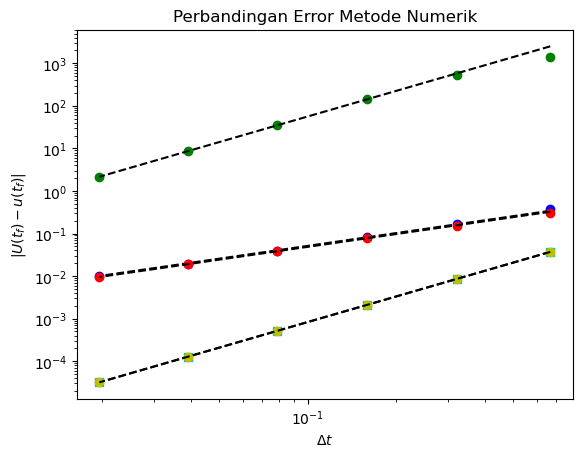

In [14]:
# Perbandingan akurasi antara Euler dan Leap-Frog

f = lambda t, u: -u
u_exact = lambda t: numpy.exp(-t)
u_0 = 1.0

t_f = 10.0
num_steps = [2**n for n in range(4, 10)]
delta_t = numpy.empty(len(num_steps))
error = numpy.empty((5, len(num_steps)))

for (i, N) in enumerate(num_steps):
    t = numpy.linspace(0, t_f, N)
    delta_t[i] = t[1] - t[0]
    
    U = numpy.empty(t.shape)
    
    # Forward Euler
    U[0] = u_0
    for n in range(t.shape[0] - 1):
        U[n + 1] = U[n] + delta_t[i] * f(t[n], U[n])
    error[0, i] = numpy.linalg.norm(delta_t[i] * (U - u_exact(t)), ord=1)
    
    # Leap-Frog
    U[0] = u_0
    U[1] = U[0] + delta_t[i] * f(t[0], U[0])
    for n in range(1, t.shape[0] - 1):
        U[n + 1] = U[n - 1] + 2.0 * delta_t[i] * f(t[n], U[n])
    error[1, i] = numpy.linalg.norm(delta_t[i] * (U - u_exact(t)), ord=1)
    
    # Backward Euler
    U[0] = u_0
    for n in range(0, t.shape[0] - 1):
        U[n + 1] = U[n] / (1.0 + delta_t[i])
    error[2, i] = numpy.linalg.norm(delta_t[i] * (U - u_exact(t)), ord=1)
    
    # Midpoint / Crank-Nicolson
    U[0] = u_0
    konstanta = (1.0 - delta_t[i] / 2.0) / (1.0 + delta_t[i] / 2.0)
    for n in range(0, t.shape[0] - 1):
        U[n + 1] = U[n] * konstanta
    error[3, i] = numpy.linalg.norm(delta_t[i] * (U - u_exact(t)), ord=1)
    
    # Trapezoidal
    U[0] = u_0
    konstanta = (1.0 - delta_t[i] / 2.0) / (1.0 + delta_t[i] / 2.0)
    for n in range(t.shape[0] - 1):
        U[n + 1] = U[n] * konstanta
    error[4, i] = numpy.linalg.norm(delta_t[i] * (U - u_exact(t)), ord=1)

# Plot error vs dt
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

order_C = lambda dx, err, order: numpy.exp(numpy.log(err) - order * numpy.log(dx))
style = ['bo', 'go', 'ro', 'cs', 'yo']
label = ['Forward Euler', "Leap-Frog", "Backward Euler", "Midpoint", "Trapezoidal"]
order = [1, 2, 1, 2, 2]

for k in range(5):
    axes.loglog(delta_t, error[k, :], style[k], label=label[k])
    axes.loglog(delta_t,
                order_C(delta_t[2], error[k, 2], order[k]) * delta_t**order[k],
                'k--')

axes.set_title("Perbandingan Error Metode Numerik")
axes.set_xlabel("$\\Delta t$")
axes.set_ylabel("$|U(t_f) - u(t_f)|$")

plt.show()

## One-Step Errors

Terdapat definisi lain dari *local truncation error* (LTE) yang disebut **one-step error** dalam metode numerik ODE. Definisi ini sedikit berbeda dari LTE sebelumnya. Pada definisi sebelumnya, kita langsung mendiskretisasi turunan, sedangkan pada definisi ini kita menuliskan skema dalam bentuk pembaruan satu langkah (*update form*).

Sebagai contoh, untuk metode leap-frog, LTE sebelumnya didasarkan pada:

$$
\frac{U_{n+1} - U_{n-1}}{2 \Delta t} = f(U_n)
$$

yang menghasilkan LTE orde dua.

Untuk **one-step error**, kita tuliskan ulang sebagai:

$$
U_{n+1} = U_{n-1} + 2 \Delta t f(U_n)
$$

yang menghasilkan one-step error sebesar $\mathcal{O}(\Delta t^3)$:

$$
\begin{aligned}
\mathcal{L}^n &= u(t_{n+1}) - u(t_{n-1}) - 2 \Delta t f(u(t_n)) \\
&= \frac{1}{3} \Delta t^3 u'''(t_n) + \mathcal{O}(\Delta t^5) \\
&= 2 \Delta t \tau^n.
\end{aligned}
$$

One-step error ini menunjukkan bahwa kesalahan per langkah mungkin lebih kecil, namun tidak selalu mencerminkan error global. Oleh karena itu, dalam analisis konvergensi kita tetap menggunakan definisi LTE sebelumnya. Secara umum, jika LTE berorde $p$, maka error global berorde $p$. Sedangkan jika one-step error berorde $p+1$, maka error global berorde $p$.

---

## Metode Taylor Series

### Taylor Series Methods

Metode Taylor dapat diturunkan dengan memasukkan fungsi $f(t,u)$ dan turunannya ke dalam ekspansi Taylor dari $u(t_{n+1})$.

Untuk metode orde $p$, kita gunakan:

$$
u(t_{n+1}) = u(t_n) + \Delta t u'(t_n) + \frac{\Delta t^2}{2} u''(t_n) + \frac{\Delta t^3}{6} u'''(t_n) + \cdots + \frac{\Delta t^p}{p!} u^{(p)}(t_n)
$$

Karena dari ODE berlaku $u'(t) = f(t,u)$, maka:

$$
u^{(p)}(t_n) = f^{(p-1)}(t_n, u(t_n))
$$

Sehingga skema menjadi:

$$
u(t_{n+1}) = u(t_n) + \Delta t f(t_n, u(t_n)) + \frac{\Delta t^2}{2} f'(t_n, u(t_n)) + \cdots + \frac{\Delta t^p}{p!} f^{(p-1)}(t_n, u(t_n)).
$$

Kelemahan utama metode ini adalah:
- setiap masalah ODE membutuhkan derivasi ulang,
- membutuhkan turunan $f$ hingga orde $p-1$.

---

## Metode Taylor Orde 2

Untuk orde 2, kita butuh turunan pertama dari ODE:

$$
u'(t) = f(t,u), \quad \Rightarrow \quad u''(t) = f'(t,u)
$$

Sehingga diperoleh:

$$
\begin{aligned}
u(t_{n+1}) &= u(t_n) + \Delta t u'(t_n) + \frac{\Delta t^2}{2} u''(t_n) \\
&= u(t_n) + \Delta t f(t_n, u(t_n)) + \frac{\Delta t^2}{2} f'(t_n, u(t_n))
\end{aligned}
$$

atau dalam bentuk diskret:

$$
U^{n+1} = U^n + \Delta t f(t_n, U^n) + \frac{\Delta t^2}{2} f'(t_n, U^n).
$$

---

## Metode Runge-Kutta

Metode orde tinggi dapat dibangun dengan menggunakan **tahapan intermediate (stages)**. Metode ini bukan multi-step karena hanya menggunakan informasi dari satu waktu, tetapi meningkatkan akurasi dengan beberapa evaluasi fungsi. Metode ini disebut **Runge-Kutta method**.

---

### Contoh: Runge-Kutta 2-tahap

Ide dasarnya adalah memperkirakan nilai di titik tengah menggunakan Euler:

$$
\begin{aligned}
U^* &= U^n + \frac{1}{2} \Delta t f(U^n) \\
U^{n+1} &= U^n + \Delta t f(U^*)
\end{aligned}
$$

---

### Contoh: Runge-Kutta 4-tahap

$$
\begin{aligned}
Y_1 &= U^n \\
Y_2 &= U^n + \frac{1}{2} \Delta t f(Y_1, t_n) \\
Y_3 &= U^n + \frac{1}{2} \Delta t f(Y_2, t_n + \Delta t / 2) \\
Y_4 &= U^n + \Delta t f(Y_3, t_n + \Delta t / 2) \\
U^{n+1} &= U^n + \frac{\Delta t}{6} \left[f(Y_1, t_n) + 2 f(Y_2, t_n + \Delta t / 2) + 2 f(Y_3, t_n + \Delta t / 2) + f(Y_4, t_n + \Delta t)\right]
\end{aligned}
$$

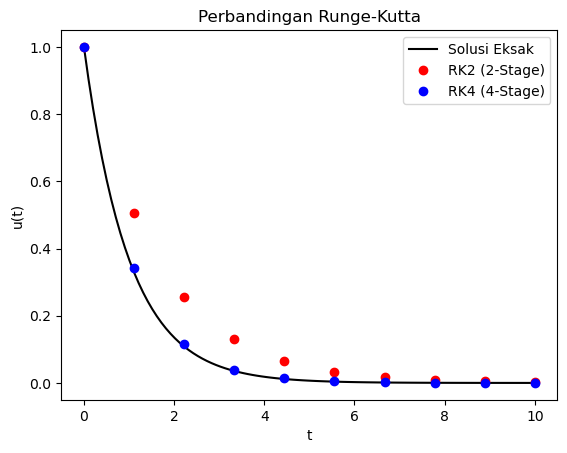

In [15]:
# Implementasi dan perbandingan metode Runge-Kutta 2-tahap dan 4-tahap

f = lambda t, u: -u

t_exact = numpy.linspace(0.0, 10.0, 100)
u_exact = numpy.exp(-t_exact)

N = 10
t = numpy.linspace(0, 10.0, N)
delta_t = t[1] - t[0]

# RK2 (2-stage Runge-Kutta)
U_2 = numpy.empty(t.shape)
U_2[0] = 1.0

for n in range(0, t.shape[0] - 1):
    y1 = U_2[n]
    y2 = U_2[n] + 0.5 * delta_t * f(t[n], y1)
    U_2[n + 1] = U_2[n] + delta_t * f(t[n] + 0.5 * delta_t, y2)

# RK4 (4-stage Runge-Kutta)
U_4 = numpy.empty(t.shape)
U_4[0] = 1.0

for n in range(0, t.shape[0] - 1):
    y1 = U_4[n]
    y2 = U_4[n] + 0.5 * delta_t * f(t[n], y1)
    y3 = U_4[n] + 0.5 * delta_t * f(t[n] + 0.5 * delta_t, y2)
    y4 = U_4[n] + delta_t * f(t[n] + 0.5 * delta_t, y3)

    U_4[n + 1] = U_4[n] + (delta_t / 6.0) * (
        f(t[n], y1)
        + 2.0 * f(t[n] + 0.5 * delta_t, y2)
        + 2.0 * f(t[n] + 0.5 * delta_t, y3)
        + f(t[n] + delta_t, y4)
    )

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.plot(t_exact, u_exact, 'k', label="Solusi Eksak")
axes.plot(t, U_2, 'ro', label="RK2 (2-Stage)")
axes.plot(t, U_4, 'bo', label="RK4 (4-Stage)")

axes.legend(loc=1)
axes.set_title("Perbandingan Runge-Kutta")
axes.set_xlabel("t")
axes.set_ylabel("u(t)")

plt.show()

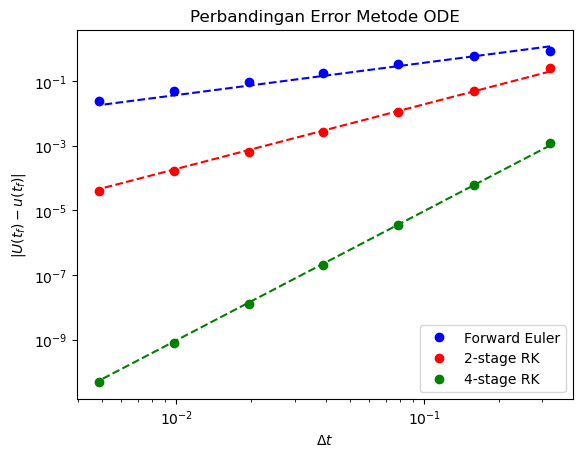

In [16]:
# Perbandingan akurasi antara Euler dan Runge-Kutta

f = lambda t, u: -u
u_exact = lambda t: numpy.exp(-t)

t_f = 10.0
num_steps = [2**n for n in range(5, 12)]

delta_t = numpy.empty(len(num_steps))
error_euler = numpy.empty(len(num_steps))
error_2 = numpy.empty(len(num_steps))
error_4 = numpy.empty(len(num_steps))

for (i, N) in enumerate(num_steps):
    t = numpy.linspace(0, t_f, N)
    delta_t[i] = t[1] - t[0]
    
    # Euler
    U_euler = numpy.empty(t.shape)
    U_euler[0] = 1.0
    for n in range(0, t.shape[0] - 1):
        U_euler[n + 1] = U_euler[n] + delta_t[i] * f(t[n], U_euler[n])
    
    # RK2 (2-stage)
    U_2 = numpy.empty(t.shape)
    U_2[0] = 1.0
    for n in range(0, t.shape[0] - 1):
        U_2[n + 1] = U_2[n] + 0.5 * delta_t[i] * f(t[n], U_2[n])
        U_2[n + 1] = U_2[n] + delta_t[i] * f(t[n] + delta_t[i], U_2[n + 1])
    
    # RK4 (4-stage)
    U_4 = numpy.empty(t.shape)
    U_4[0] = 1.0
    for n in range(0, t.shape[0] - 1):
        y1 = U_4[n]
        y2 = U_4[n] + 0.5 * delta_t[i] * f(t[n], y1)
        y3 = U_4[n] + 0.5 * delta_t[i] * f(t[n] + 0.5 * delta_t[i], y2)
        y4 = U_4[n] + delta_t[i] * f(t[n] + 0.5 * delta_t[i], y3)

        U_4[n + 1] = U_4[n] + (delta_t[i] / 6.0) * (
            f(t[n], y1)
            + 2.0 * f(t[n] + 0.5 * delta_t[i], y2)
            + 2.0 * f(t[n] + 0.5 * delta_t[i], y3)
            + f(t[n] + delta_t[i], y4)
        )

    # Error relatif di t_f
    error_euler[i] = numpy.abs(U_euler[-1] - u_exact(t_f)) / numpy.abs(u_exact(t_f))
    error_2[i] = numpy.abs(U_2[-1] - u_exact(t_f)) / numpy.abs(u_exact(t_f))
    error_4[i] = numpy.abs(U_4[-1] - u_exact(t_f)) / numpy.abs(u_exact(t_f))

# Plot error vs dt
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.loglog(delta_t, error_euler, 'bo', label='Forward Euler')
axes.loglog(delta_t, error_2, 'ro', label='2-stage RK')
axes.loglog(delta_t, error_4, 'go', label="4-stage RK")

order_C = lambda dx, err, order: numpy.exp(numpy.log(err) - order * numpy.log(dx))

axes.loglog(delta_t,
            order_C(delta_t[1], error_euler[1], 1.0) * delta_t**1.0,
            '--b')

axes.loglog(delta_t,
            order_C(delta_t[1], error_2[1], 2.0) * delta_t**2.0,
            '--r')

axes.loglog(delta_t,
            order_C(delta_t[1], error_4[1], 4.0) * delta_t**4.0,
            '--g')

axes.legend(loc=4)
axes.set_title("Perbandingan Error Metode ODE")
axes.set_xlabel("$\\Delta t$")
axes.set_ylabel("$|U(t_f) - u(t_f)|$")

plt.show()

## Metode Multi-Langkah Linear (Linear Multi-Step Methods)

Metode multi-langkah (seperti yang diperkenalkan melalui metode leap-frog) adalah metode penyelesaian ODE yang membutuhkan lebih dari satu titik waktu sebelumnya untuk menghitung solusi berikutnya.

Beberapa keuntungan menggunakan metode multi-langkah dibandingkan metode satu-langkah:

- Metode berbasis deret Taylor memerlukan turunan persamaan yang diberikan, yang bisa menjadi rumit dan sulit diimplementasikan.
- Metode satu-langkah berorde tinggi sering kali membutuhkan evaluasi fungsi $f$ berkali-kali dalam satu langkah waktu.

Kekurangan:

- Metode ini tidak self-starting, artinya membutuhkan metode lain untuk menghasilkan nilai awal.
- Ukuran langkah waktu $\Delta t$ sulit diubah secara adaptif dibandingkan metode satu-langkah.

---

### Metode Multi-Langkah Linear Umum

Semua metode multi-langkah linear dapat ditulis sebagai kombinasi linear dari solusi masa lalu, sekarang, dan masa depan:

$$
\sum_{j=0}^{r} \alpha_j U^{n+j}
=
\Delta t \sum_{j=0}^{r} \beta_j f(U^{n+j}, t_{n+j})
$$

Jika $\beta_r = 0$, maka metode tersebut bersifat eksplisit (tidak melibatkan nilai masa depan yang belum diketahui).

Perlu dicatat bahwa koefisien tidak unik karena kedua sisi dapat dikalikan dengan konstanta yang sama. Dalam praktiknya biasanya digunakan normalisasi $\alpha_r = 1$.

---

### Contoh: Metode Adams

$$
U^{n+r} = U^{n+r-1} + \Delta t \sum_{j=0}^{r} \beta_j f(U^{n+j})
$$

Semua metode ini memiliki:
- $\alpha_r = 1$
- $\alpha_{r-1} = -1$
- $\alpha_j = 0$ untuk $j < r-1$

Perbedaan antar metode ditentukan oleh cara memilih koefisien $\beta_j$.

---

### Metode Adams-Bashforth

Metode **Adams-Bashforth** adalah metode eksplisit yang dirancang untuk memaksimalkan orde akurasi untuk jumlah langkah $r$ tertentu. Koefisien $\beta_j$ dipilih dengan mencocokkan ekspansi deret Taylor dan menghilangkan sebanyak mungkin suku error.

Contoh beberapa metode Adams-Bashforth:

$$
\begin{aligned}
\text{1-step:} \quad & U_{n+1} = U_n + \Delta t\, f(U_n) \\
\text{2-step:} \quad & U_{n+2} = U_{n+1} + \frac{\Delta t}{2}\left(-f(U_n) + 3f(U_{n+1})\right) \\
\text{3-step:} \quad & U_{n+3} = U_{n+2} + \frac{\Delta t}{12}\left(5f(U_n) - 16f(U_{n+1}) + 23f(U_{n+2})\right) \\
\text{4-step:} \quad & U_{n+4} = U_{n+3} + \frac{\Delta t}{24}\left(-9f(U_n) + 37f(U_{n+1}) - 59f(U_{n+2}) + 55f(U_{n+3})\right)
\end{aligned}
$$

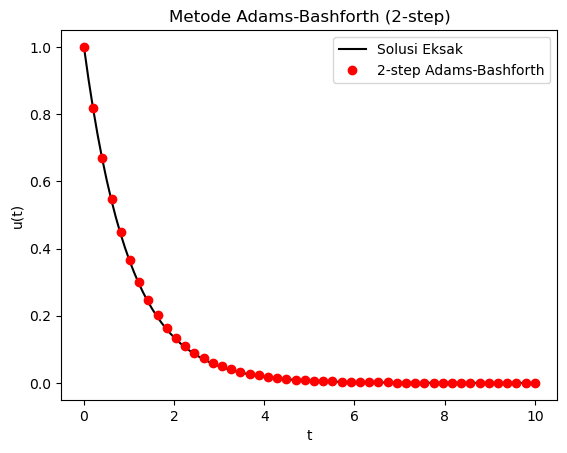

In [17]:
# Use 2-step Adams-Bashforth to compute solution

f = lambda t, u: -u

t_exact = numpy.linspace(0.0, 10.0, 100)
u_exact = numpy.exp(-t_exact)

N = 50
t = numpy.linspace(0, 10.0, N)
delta_t = t[1] - t[0]

U = numpy.empty(t.shape)

# Start method (needs 2 initial values)
U[0] = 1.0

# Use a one-step method (RK2 / improved Euler) to get U[1]
k1 = f(t[0], U[0])
k2 = f(t[0] + delta_t, U[0] + delta_t * k1)
U[1] = U[0] + (delta_t / 2.0) * (k1 + k2)

# 2-step Adams-Bashforth method
for n in range(0, len(t) - 2):
    U[n + 2] = U[n + 1] + (delta_t / 2.0) * (
        -f(t[n], U[n]) + 3.0 * f(t[n + 1], U[n + 1])
    )

# Plot hasil
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.plot(t_exact, u_exact, 'k', label="Solusi Eksak")
axes.plot(t, U, 'ro', label="2-step Adams-Bashforth")

axes.set_title("Metode Adams-Bashforth (2-step)")
axes.set_xlabel("t")
axes.set_ylabel("u(t)")
axes.legend(loc=1)

plt.show()

## Metode Adams–Moulton

Metode **Adams–Moulton** adalah versi *implisit* dari metode Adams–Bashforth. Karena melibatkan nilai fungsi pada titik waktu yang belum diketahui (future step), metode ini termasuk dalam kelas metode implisit.

Dengan adanya tambahan parameter $\beta_r$, metode ini umumnya memiliki orde akurasi **satu tingkat lebih tinggi** dibandingkan metode Adams–Bashforth yang bersesuaian.

---

### Bentuk Umum (contoh beberapa orde)

$$
\begin{aligned}
\text{1-step:} \quad & U_{n+1} = U_n + \frac{\Delta t}{2}\left(f(U_n) + f(U_{n+1})\right) \\
\\
\text{2-step:} \quad & U_{n+2} = U_{n+1} + \frac{\Delta t}{12}\left(-f(U_n) + 8f(U_{n+1}) + 5f(U_{n+2})\right) \\
\\
\text{3-step:} \quad & U_{n+3} = U_{n+2} + \frac{\Delta t}{24}\left(f(U_n) - 5f(U_{n+1}) + 19f(U_{n+2}) + 9f(U_{n+3})\right) \\
\\
\text{4-step:} \quad & U_{n+4} = U_{n+3} + \frac{\Delta t}{720}\left(-19 f(U_n) + 106 f(U_{n+1}) - 264 f(U_{n+2}) + 646 f(U_{n+3}) + 251 f(U_{n+4})\right)
\end{aligned}
$$

---

### Catatan penting
- Karena bersifat **implisit**, metode ini membutuhkan penyelesaian persamaan (sering non-linear) pada setiap langkah waktu.
- Namun, sebagai kompensasi, metode ini:
  - lebih stabil dibanding metode eksplisit,
  - dan umumnya memiliki akurasi lebih tinggi untuk orde yang sama.

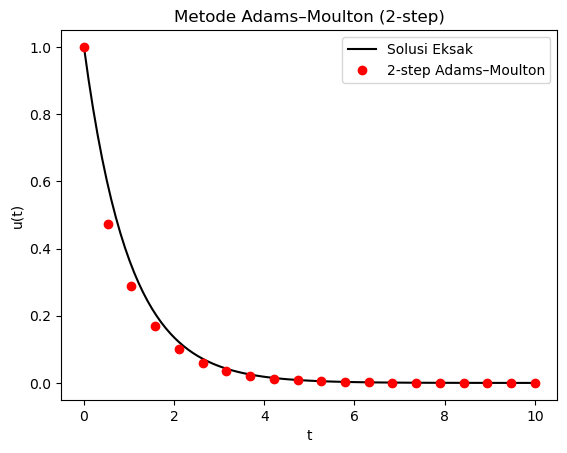

In [18]:
# 2-step Adams–Moulton method implementation

# u' = -decay * u
decay_constant = 1.0
f = lambda t, u: -decay_constant * u

t_exact = numpy.linspace(0.0, 10.0, 100)
u_exact = numpy.exp(-t_exact)

N = 20
t = numpy.linspace(0, 10.0, N)
delta_t = t[1] - t[0]

U = numpy.empty(t.shape)

# Initial condition
U[0] = 1.0

# Start value using a one-step method (Euler / predictor)
U[1] = U[0] + delta_t * f(t[0], U[0])

# 2-step Adams–Moulton (implicit method rearranged)
# U[n+2] = U[n+1] + dt/12 * (-f_n + 8 f_{n+1} + 5 f_{n+2})
# for linear case f = -u, can be solved explicitly

alpha = 1.0 / (1.0 + (5.0 * decay_constant * delta_t / 12.0))

for n in range(0, t.shape[0] - 2):
    U[n + 2] = alpha * (
        U[n + 1]
        + (decay_constant * delta_t / 12.0) * (U[n] - 8.0 * U[n + 1])
    )

# Plot hasil
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.plot(t_exact, u_exact, 'k', label="Solusi Eksak")
axes.plot(t, U, 'ro', label="2-step Adams–Moulton")

axes.set_title("Metode Adams–Moulton (2-step)")
axes.set_xlabel("t")
axes.set_ylabel("u(t)")
axes.legend(loc=1)

plt.show()

## Truncation Error untuk Metode Multi-Langkah

Kita dapat menentukan truncation error (kesalahan pemotongan) untuk metode linear multi-step secara umum sebagai berikut:

$$
\tau^n =
\frac{1}{\Delta t}
\left[
\sum_{j=0}^{r} \alpha_j u(t_{n+j})
-
\Delta t \sum_{j=0}^{r} \beta_j f(t_{n+j}, u(t_{n+j}))
\right]
$$

---

Dengan menggunakan ekspansi Taylor di sekitar $t_n$, kita peroleh:

$$
\begin{aligned}
u(t_{n+j}) &= u(t_n) + j\Delta t\, u'(t_n) + \frac{1}{2}(j\Delta t)^2 u''(t_n) + \mathcal{O}(\Delta t^3), \\
\\
u'(t_{n+j}) &= u'(t_n) + j\Delta t\, u''(t_n) + \frac{1}{2}(j\Delta t)^2 u'''(t_n) + \mathcal{O}(\Delta t^3)
\end{aligned}
$$

---

Substitusi ke dalam definisi truncation error menghasilkan:

$$
\begin{aligned}
\tau^n &= \frac{1}{\Delta t}\left(\sum_{j=0}^{r} \alpha_j\right) u(t_n)
+ \left(\sum_{j=0}^{r} (j\alpha_j - \beta_j)\right) u'(t_n) \\
&\quad + \Delta t \left(\sum_{j=0}^{r} \left(\frac{1}{2}j^2 \alpha_j - j\beta_j\right)\right) u''(t_n)
+ \cdots \\
&\quad + \Delta t^{q-1}\left(\sum_{j=0}^{r} \left(\frac{1}{q!} j^q \alpha_j - \frac{1}{(q-1)!} j^{q-1}\beta_j\right)\right) u^{(q)}(t_n)
+ \cdots
\end{aligned}
$$

---

## Konsistensi Metode

Metode dikatakan **konsisten** jika suku-suku dominan pertama dari ekspansi error hilang, yaitu:

### 1. Syarat pertama:
$$
\sum_{j=0}^{r} \alpha_j = 0
$$

### 2. Syarat kedua:
$$
\sum_{j=0}^{r} j\alpha_j = \sum_{j=0}^{r} \beta_j
$$

---

Jika kedua syarat ini terpenuhi, maka metode tidak memiliki error dominan orde $\mathcal{O}(1)$ atau $\mathcal{O}(\Delta t^{-1})$, sehingga bisa dianggap **konsisten** terhadap ODE yang diberikan.

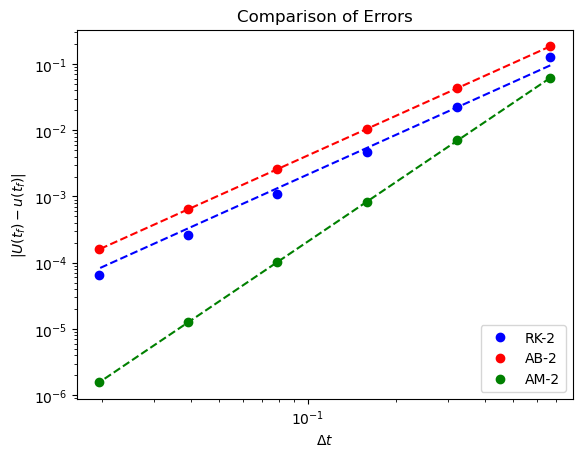

In [19]:
# Compare accuracy between RK-2, AB-2, and AM-2

f = lambda t, u: -u
u_exact = lambda t: numpy.exp(-t)

t_f = 10.0
num_steps = [2**n for n in range(4, 10)]

delta_t = numpy.empty(len(num_steps))
error_rk = numpy.empty(len(num_steps))
error_ab = numpy.empty(len(num_steps))
error_am = numpy.empty(len(num_steps))

for i, N in enumerate(num_steps):
    t = numpy.linspace(0, t_f, N)
    delta_t[i] = t[1] - t[0]

    # -------------------
    # RK2 (2-stage)
    # -------------------
    U_rk = numpy.empty(t.shape)
    U_rk[0] = 1.0

    for n in range(0, t.shape[0] - 1):
        y1 = U_rk[n]
        y2 = U_rk[n] + 0.5 * delta_t[i] * f(t[n], y1)
        U_rk[n + 1] = U_rk[n] + delta_t[i] * f(t[n] + 0.5 * delta_t[i], y2)

    # -------------------
    # AB2 (Adams–Bashforth 2-step)
    # -------------------
    U_ab = numpy.empty(t.shape)
    U_ab[:2] = U_rk[:2]  # start from RK2

    for n in range(0, t.shape[0] - 2):
        U_ab[n + 2] = U_ab[n + 1] + (delta_t[i] / 2.0) * (
            -f(t[n], U_ab[n]) + 3.0 * f(t[n + 1], U_ab[n + 1])
        )

    # -------------------
    # AM2 (Adams–Moulton 2-step)
    # -------------------
    U_am = numpy.empty(t.shape)
    U_am[:2] = U_rk[:2]  # start from RK2

    decay_constant = 1.0
    alpha = 1.0 / (1.0 + 5.0 * decay_constant * delta_t[i] / 12.0)

    for n in range(0, t.shape[0] - 2):
        U_am[n + 2] = alpha * (
            U_am[n + 1]
            + (decay_constant * delta_t[i] / 12.0) * (U_am[n] - 8.0 * U_am[n + 1])
        )

    # -------------------
    # Error computation
    # -------------------
    error_rk[i] = numpy.linalg.norm(delta_t[i] * (U_rk - u_exact(t)), ord=1)
    error_ab[i] = numpy.linalg.norm(delta_t[i] * (U_ab - u_exact(t)), ord=1)
    error_am[i] = numpy.linalg.norm(delta_t[i] * (U_am - u_exact(t)), ord=1)

# -------------------
# Plot results
# -------------------
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.loglog(delta_t, error_rk, 'bo', label='RK-2')
axes.loglog(delta_t, error_ab, 'ro', label='AB-2')
axes.loglog(delta_t, error_am, 'go', label='AM-2')

order_C = lambda dx, err, p: numpy.exp(numpy.log(err) - p * numpy.log(dx))

axes.loglog(delta_t,
            order_C(delta_t[1], error_rk[1], 2.0) * delta_t**2.0,
            '--b')

axes.loglog(delta_t,
            order_C(delta_t[1], error_ab[1], 2.0) * delta_t**2.0,
            '--r')

axes.loglog(delta_t,
            order_C(delta_t[1], error_am[1], 3.0) * delta_t**3.0,
            '--g')

axes.legend(loc=4)
axes.set_title("Comparison of Errors")
axes.set_xlabel("$\\Delta t$")
axes.set_ylabel("$|U(t_f) - u(t_f)|$")

plt.show()

## Metode Predictor–Corrector

Salah satu cara untuk menyederhanakan metode Adams–Moulton agar tidak perlu menyelesaikan sistem implisit adalah dengan mengganti nilai fungsi yang belum diketahui menggunakan estimasi dari metode eksplisit.

Metode seperti ini disebut **predictor–corrector**, karena terdiri dari dua tahap:

- **Predictor (prediksi):** memperkirakan nilai solusi di waktu berikutnya menggunakan metode eksplisit.
- **Corrector (koreksi):** memperbaiki hasil prediksi menggunakan metode implisit.

---

## Contoh: One-Step Adams–Bashforth–Moulton

Kita menggunakan:

### 1. Predictor (Adams–Bashforth 1-step / Euler eksplisit)

$$
\hat{U}^{n+1} = U^n + \Delta t\, f(U^n)
$$

### 2. Corrector (Adams–Moulton 1-step)

$$
U^{n+1} = U^n + \frac{1}{2}\Delta t \left(f(U^n) + f(\hat{U}^{n+1})\right)
$$

---

## Catatan Penting

- Metode ini menghindari penyelesaian persamaan implisit karena $f(U^{n+1})$ diganti dengan $f(\hat{U}^{n+1})$.
- Kombinasi predictor–corrector ini menghasilkan metode dengan **orde akurasi 2**.

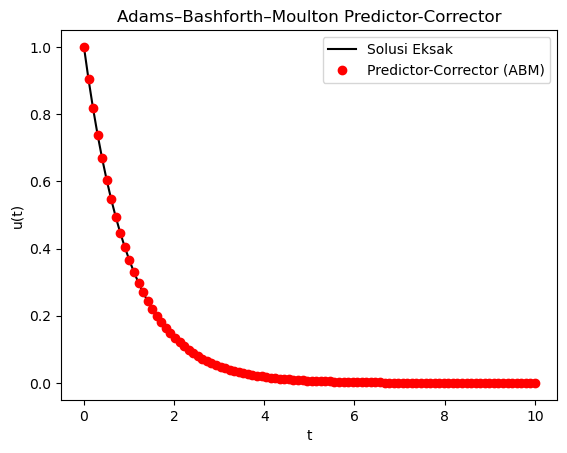

In [20]:
# One-step Adams-Bashforth–Moulton (Predictor–Corrector)

f = lambda t, u: -u

t_exact = numpy.linspace(0.0, 10.0, 100)
u_exact = numpy.exp(-t_exact)

N = 100
t = numpy.linspace(0, 10.0, N)
delta_t = t[1] - t[0]

U = numpy.empty(t.shape)

# initial condition
U[0] = 1.0

# Predictor–Corrector loop
for n in range(0, t.shape[0] - 1):
    
    # Predictor (Adams–Bashforth / Forward Euler)
    U_pred = U[n] + delta_t * f(t[n], U[n])
    
    # Corrector (Adams–Moulton trapezoidal form)
    U[n + 1] = U[n] + 0.5 * delta_t * (
        f(t[n], U[n]) + f(t[n + 1], U_pred)
    )

# Plot hasil
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.plot(t_exact, u_exact, 'k', label="Solusi Eksak")
axes.plot(t, U, 'ro', label="Predictor-Corrector (ABM)")

axes.set_title("Adams–Bashforth–Moulton Predictor-Corrector")
axes.set_xlabel("t")
axes.set_ylabel("u(t)")
axes.legend(loc=1)

plt.show()

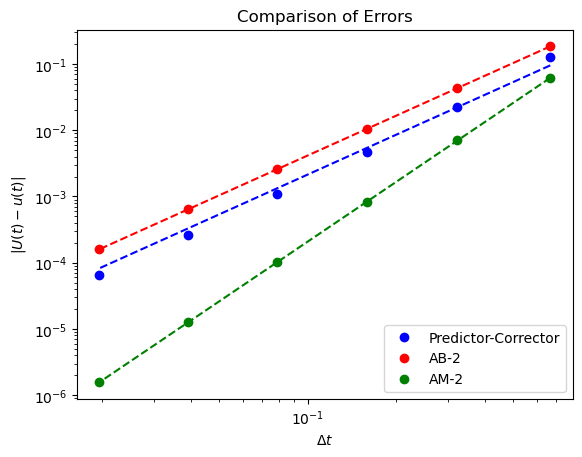

In [21]:
# Compare accuracy between RK-2, AB-2, AM-2, and Predictor-Corrector

f = lambda t, u: -u
u_exact = lambda t: numpy.exp(-t)

t_f = 10.0
num_steps = [2**n for n in range(4, 10)]

delta_t = numpy.empty(len(num_steps))
error_ab = numpy.empty(len(num_steps))
error_am = numpy.empty(len(num_steps))
error_pc = numpy.empty(len(num_steps))

for i, N in enumerate(num_steps):
    t = numpy.linspace(0, t_f, N)
    delta_t[i] = t[1] - t[0]

    # -----------------------
    # Bootstrap (RK2 for AB & AM)
    # -----------------------
    U_rk = numpy.empty(2)
    U_rk[0] = 1.0

    k1 = f(t[0], U_rk[0])
    k2 = f(t[0] + delta_t[i], U_rk[0] + delta_t[i] * k1)
    U_rk[1] = U_rk[0] + 0.5 * delta_t[i] * (k1 + k2)

    # -----------------------
    # Adams-Bashforth 2-step
    # -----------------------
    U_ab = numpy.empty(t.shape)
    U_ab[:2] = U_rk[:2]

    for n in range(0, t.shape[0] - 2):
        U_ab[n + 2] = U_ab[n + 1] + (delta_t[i] / 2.0) * (
            -f(t[n], U_ab[n]) + 3.0 * f(t[n + 1], U_ab[n + 1])
        )

    # -----------------------
    # Adams-Moulton 2-step
    # -----------------------
    U_am = numpy.empty(t.shape)
    U_am[:2] = U_ab[:2]

    decay_constant = 1.0
    alpha = 1.0 / (1.0 + 5.0 * decay_constant * delta_t[i] / 12.0)

    for n in range(0, t.shape[0] - 2):
        U_am[n + 2] = alpha * (
            U_am[n + 1]
            + (decay_constant * delta_t[i] / 12.0) * (U_am[n] - 8.0 * U_am[n + 1])
        )

    # -----------------------
    # Predictor-Corrector (AB + AM 1-step)
    # -----------------------
    U_pc = numpy.empty(t.shape)
    U_pc[0] = 1.0

    for n in range(0, t.shape[0] - 1):
        # Predictor (Euler / AB1)
        U_pred = U_pc[n] + delta_t[i] * f(t[n], U_pc[n])

        # Corrector (Trapezoidal / AM1)
        U_pc[n + 1] = U_pc[n] + 0.5 * delta_t[i] * (
            f(t[n], U_pc[n]) + f(t[n + 1], U_pred)
        )

    # -----------------------
    # Error computation
    # -----------------------
    error_ab[i] = numpy.linalg.norm(delta_t[i] * (U_ab - u_exact(t)), ord=1)
    error_am[i] = numpy.linalg.norm(delta_t[i] * (U_am - u_exact(t)), ord=1)
    error_pc[i] = numpy.linalg.norm(delta_t[i] * (U_pc - u_exact(t)), ord=1)

# -----------------------
# Plot error vs dt
# -----------------------
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.loglog(delta_t, error_pc, 'bo', label='Predictor-Corrector')
axes.loglog(delta_t, error_ab, 'ro', label='AB-2')
axes.loglog(delta_t, error_am, 'go', label='AM-2')

order_C = lambda dx, err, p: numpy.exp(numpy.log(err) - p * numpy.log(dx))

axes.loglog(delta_t,
            order_C(delta_t[1], error_pc[1], 2.0) * delta_t**2.0,
            '--b')

axes.loglog(delta_t,
            order_C(delta_t[1], error_ab[1], 2.0) * delta_t**2.0,
            '--r')

axes.loglog(delta_t,
            order_C(delta_t[1], error_am[1], 3.0) * delta_t**3.0,
            '--g')

axes.legend(loc=4)
axes.set_title("Comparison of Errors")
axes.set_xlabel("$\\Delta t$")
axes.set_ylabel("$|U(t) - u(t)|$")

plt.show()